In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.initializers import RandomNormal, GlorotNormal, HeNormal

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [2]:
X, y = make_classification(
    n_samples=5000,
    n_features=20,
    n_informative=15,
    n_redundant=5,
    n_classes=2,
    random_state=42
)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Standardization
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(X_train.shape)

(4000, 20)


In [3]:
def build_model(initializer):

    model = Sequential([

        Dense(
            128,
            activation='relu',
            kernel_initializer=initializer,
            input_shape=(20,)
        ),

        Dense(
            64,
            activation='relu',
            kernel_initializer=initializer
        ),

        Dense(
            32,
            activation='relu',
            kernel_initializer=initializer
        ),

        Dense(
            1,
            activation='sigmoid'
        )
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

In [4]:
small_random = RandomNormal(
    mean=0.0,
    stddev=0.01
)

model_small = build_model(small_random)

history_small = model_small.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=30,
    batch_size=32,
    verbose=0
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
xavier = GlorotNormal()

model_xavier = build_model(xavier)

history_xavier = model_xavier.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=30,
    batch_size=32,
    verbose=0
)

In [6]:
he = HeNormal()

model_he = build_model(he)

history_he = model_he.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=30,
    batch_size=32,
    verbose=0
)

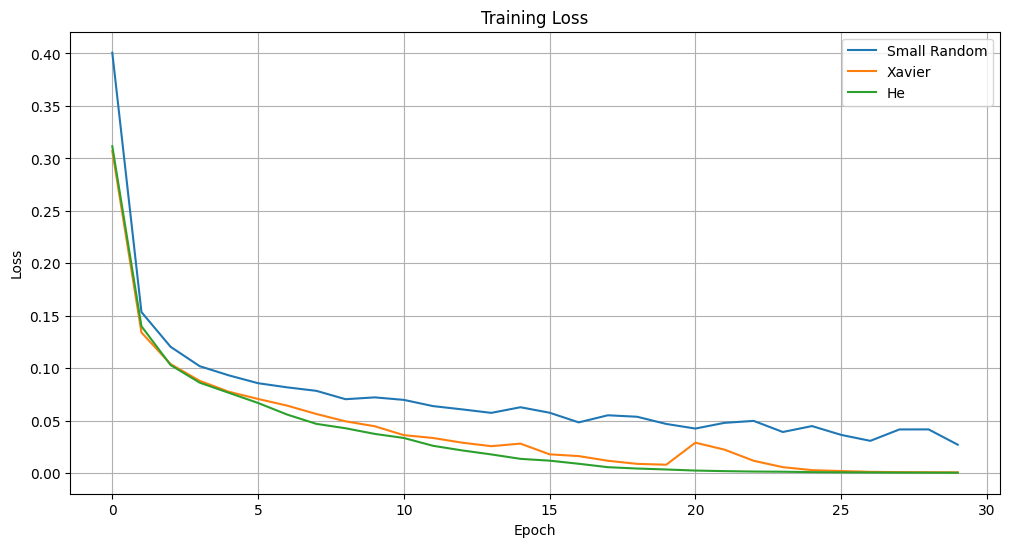

In [7]:
plt.figure(figsize=(12,6))

plt.plot(
    history_small.history['loss'],
    label='Small Random'
)

plt.plot(
    history_xavier.history['loss'],
    label='Xavier'
)

plt.plot(
    history_he.history['loss'],
    label='He'
)

plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

**Plot Validation Loss**

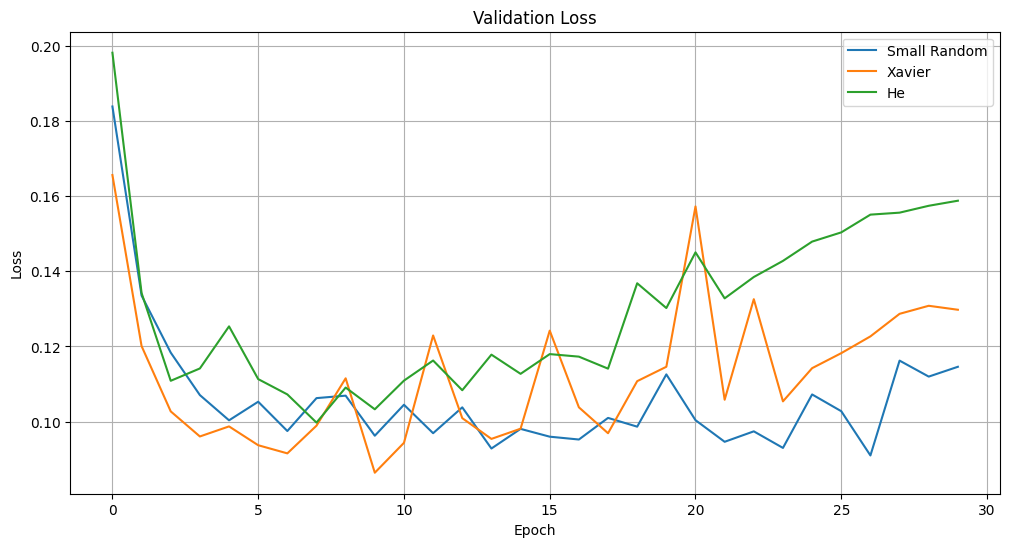

In [8]:
plt.figure(figsize=(12,6))

plt.plot(
    history_small.history['val_loss'],
    label='Small Random'
)

plt.plot(
    history_xavier.history['val_loss'],
    label='Xavier'
)

plt.plot(
    history_he.history['val_loss'],
    label='He'
)

plt.title("Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

**Plot Accuracy Comparison**

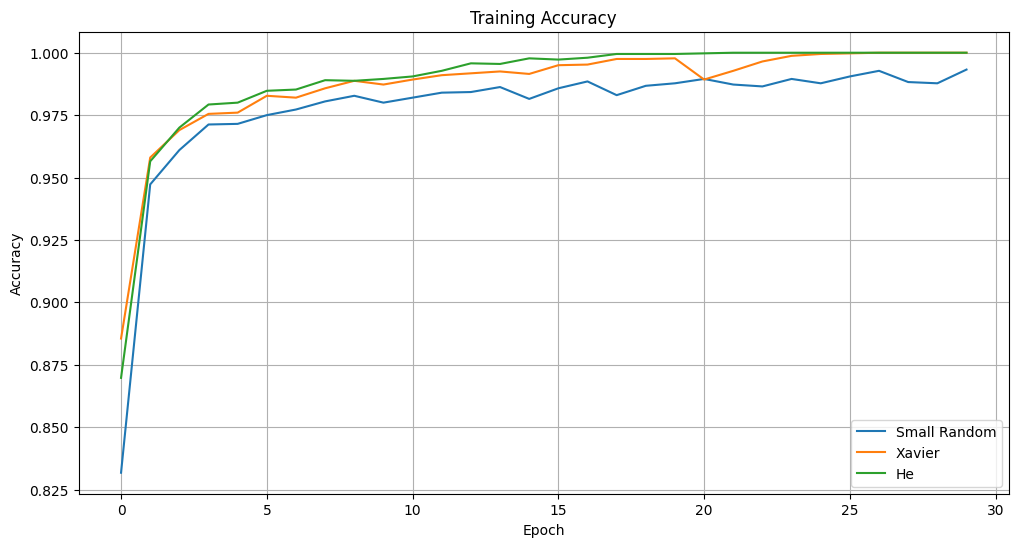

In [9]:
plt.figure(figsize=(12,6))

plt.plot(
    history_small.history['accuracy'],
    label='Small Random'
)

plt.plot(
    history_xavier.history['accuracy'],
    label='Xavier'
)

plt.plot(
    history_he.history['accuracy'],
    label='He'
)

plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()